# Model Training — E-commerce Return Prediction


## Objective
Train and compare multiple ML models to predict product returns.

**Approach:**
- Compare 5 models: Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost
- Each model trained twice — with SMOTE and with Class Weights
- Select best model based on Recall and ROC-AUC
- Save final model for deployment

### Import libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import balanced_accuracy_score
# Metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    recall_score,
    f1_score,
    precision_score,
    accuracy_score,
    RocCurveDisplay
)

import pickle
import os



## 1. Load Processed Data
Loading preprocessed train and test sets saved from feature engineering notebook.

In [3]:
# SMOTE balanced data — for Model Set 1
X_train_smote = pd.read_csv("../data/processed/X_train_smote.csv")
y_train_smote = pd.read_csv("../data/processed/y_train_smote.csv").values.ravel()

# Original imbalanced data — for Model Set 2 (Class Weights)
X_train_original = pd.read_csv("../data/processed/X_train_original.csv")
y_train_original = pd.read_csv("../data/processed/y_train_original.csv").values.ravel()

# Test data — same for both
X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

print(f"X_train SMOTE:    {X_train_smote.shape}")
print(f"X_train Original: {X_train_original.shape}")
print(f"X_test:           {X_test.shape}")
print(f"\nClass distribution in SMOTE train:")
print(pd.Series(y_train_smote).value_counts())
print(f"\nClass distribution in Original train:")
print(pd.Series(y_train_original).value_counts())

X_train SMOTE:    (14974, 25)
X_train Original: (8000, 25)
X_test:           (2000, 25)

Class distribution in SMOTE train:
0    7487
1    7487
Name: count, dtype: int64

Class distribution in Original train:
0    7487
1     513
Name: count, dtype: int64


## 2. Define Models

Two sets of models:
- **Set 1:** Trained on SMOTE balanced data
- **Set 2:** Trained with class_weight="balanced" on original data

In [ ]:
# Set 1 — SMOTE models (no class_weight needed, data already balanced)
models_smote = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree":       DecisionTreeClassifier(random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=42),
    "XGBoost":             XGBClassifier(random_state=42, eval_metric="logloss",
                                         verbosity=0)
}

# Set 2 — Class Weights models (handles imbalance algorithmically)
models_classweight = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42,
                                               class_weight="balanced"),
    "Decision Tree":       DecisionTreeClassifier(random_state=42,
                                                   class_weight="balanced"),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42,
                                                   class_weight="balanced"),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=42),
    "XGBoost":             XGBClassifier(random_state=42, eval_metric="logloss",
                                         verbosity=0,
                                         scale_pos_weight=len(y_train_original[y_train_original==0]) /
                                                          len(y_train_original[y_train_original==1]))
}



✅ Models defined successfully

SMOTE models:        ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost']
Class Weight models: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost']


## 3. Train and Evaluate All Models

**Why these metrics:**
- **Recall** → Most important — catching actual returns (minimize false negatives)
- **Precision** → How many flagged returns are real
- **F1 Score** → Balance between precision and recall
- **ROC-AUC** → Overall model discrimination ability
- **Accuracy** → Least important due to class imbalance

In [11]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test, technique):
    """Train model and return evaluation metrics."""
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    results = {
        "Model":     name,
        "Technique": technique,
        "Accuracy" :  round(accuracy_score(y_test, y_pred) * 100, 2),
        "BalancedAccuracy":  round(balanced_accuracy_score(y_test, y_pred) * 100, 2),
        "Recall":    round(recall_score(y_test, y_pred) * 100, 2),
        "Precision": round(precision_score(y_test, y_pred) * 100, 2),
        "F1 Score":  round(f1_score(y_test, y_pred) * 100, 2),
        "ROC-AUC":   round(roc_auc_score(y_test, y_prob) * 100, 2)
    }
    
    return results, model

In [12]:
# train all the models 

all_results = []
trained_models = {}

print("🚀 Training SMOTE models...\n")
for name, model in models_smote.items():
    print(f"  Training {name}...")
    results, trained = evaluate_model(
        name, model,
        X_train_smote, y_train_smote,
        X_test, y_test,
        technique="SMOTE"
    )
    all_results.append(results)
    trained_models[f"{name}_SMOTE"] = trained
    print(f"  ✅ Recall: {results['Recall']}% | ROC-AUC: {results['ROC-AUC']}%\n")

print("🚀 Training Class Weight models...\n")
for name, model in models_classweight.items():
    print(f"  Training {name}...")
    results, trained = evaluate_model(
        name, model,
        X_train_original, y_train_original,
        X_test, y_test,
        technique="Class Weights"
    )
    all_results.append(results)
    trained_models[f"{name}_ClassWeights"] = trained
    print(f"  ✅ Recall: {results['Recall']}% | ROC-AUC: {results['ROC-AUC']}%\n")

print("✅ All models trained successfully!")

🚀 Training SMOTE models...

  Training Logistic Regression...
  ✅ Recall: 24.22% | ROC-AUC: 52.34%

  Training Decision Tree...
  ✅ Recall: 10.16% | ROC-AUC: 47.79%

  Training Random Forest...
  ✅ Recall: 3.91% | ROC-AUC: 51.08%

  Training Gradient Boosting...
  ✅ Recall: 5.47% | ROC-AUC: 50.42%

  Training XGBoost...
  ✅ Recall: 2.34% | ROC-AUC: 48.63%

🚀 Training Class Weight models...

  Training Logistic Regression...
  ✅ Recall: 53.91% | ROC-AUC: 53.07%

  Training Decision Tree...
  ✅ Recall: 9.38% | ROC-AUC: 51.4%

  Training Random Forest...
  ✅ Recall: 0.0% | ROC-AUC: 51.74%

  Training Gradient Boosting...
  ✅ Recall: 0.78% | ROC-AUC: 52.51%

  Training XGBoost...
  ✅ Recall: 2.34% | ROC-AUC: 49.01%

✅ All models trained successfully!


## 4. Compare Results

Comparing all 10 models (5 × SMOTE + 5 × Class Weights)
sorted by Recall — our most important metric.


In [13]:
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values("Recall", ascending=False)

print("📊 Model Comparison (sorted by Recall):")
print(results_df.to_string(index=False))

📊 Model Comparison (sorted by Recall):
              Model     Technique  Accuracy  BalancedAccuracy  Recall  Precision  F1 Score  ROC-AUC
Logistic Regression Class Weights     54.00             53.96   53.91       7.42     13.04    53.07
Logistic Regression         SMOTE     73.20             50.38   24.22       6.60     10.37    52.34
      Decision Tree         SMOTE     80.60             47.79   10.16       4.55      6.28    47.79
      Decision Tree Class Weights     88.05             51.40    9.38       8.89      9.13    51.40
  Gradient Boosting         SMOTE     87.60             49.34    5.47       5.22      5.34    50.42
      Random Forest         SMOTE     91.30             50.59    3.91       8.93      5.43    51.08
            XGBoost         SMOTE     91.70             50.08    2.34       6.82      3.49    48.63
            XGBoost Class Weights     92.15             50.32    2.34       8.57      3.68    49.01
  Gradient Boosting Class Weights     93.65             50.39

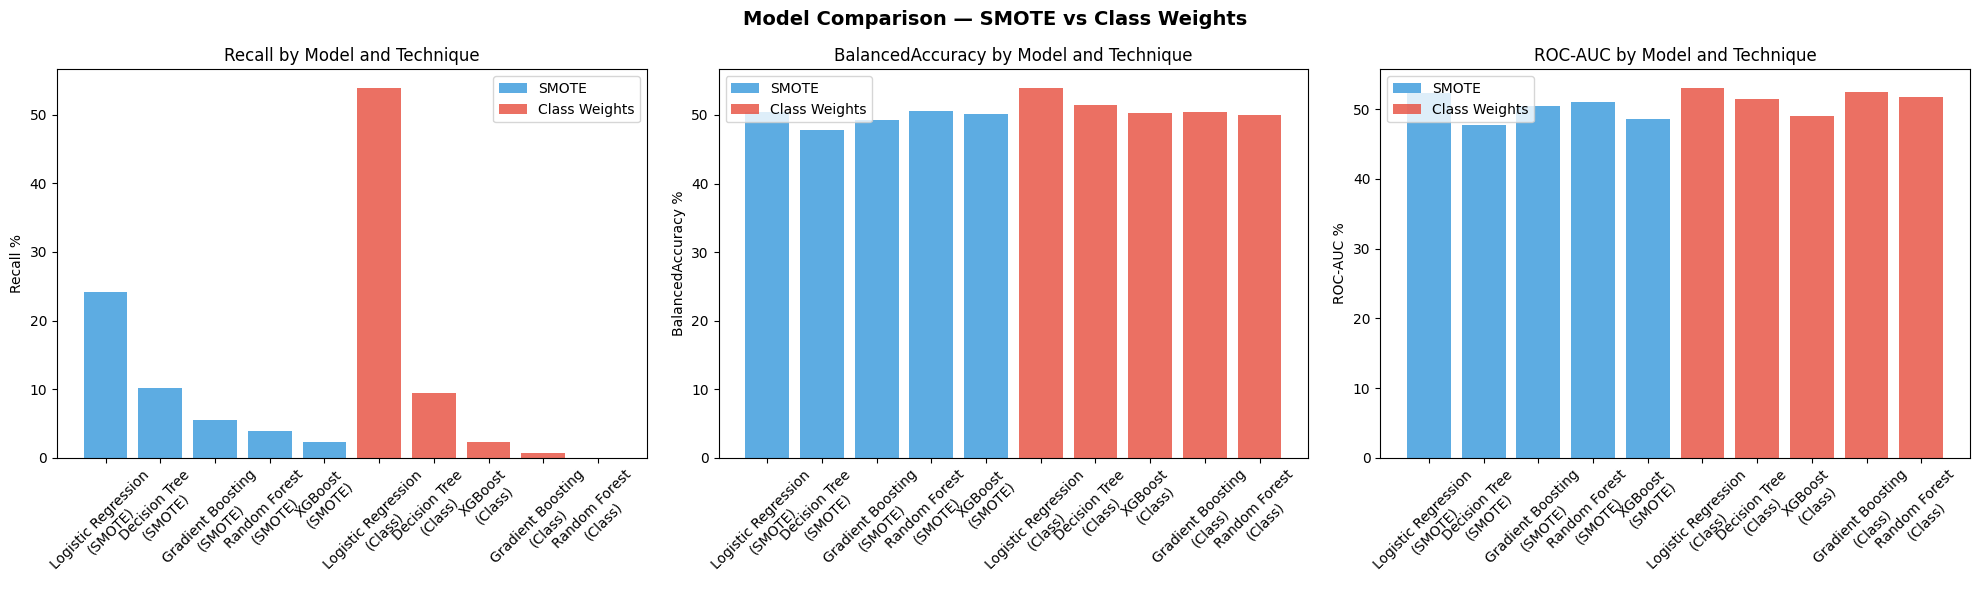

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Model Comparison — SMOTE vs Class Weights",
             fontsize=14, fontweight="bold")

metrics = ["Recall", "BalancedAccuracy", "ROC-AUC"]
colors  = {"SMOTE": "#3498db", "Class Weights": "#e74c3c"}

for idx, metric in enumerate(metrics):
    for technique in ["SMOTE", "Class Weights"]:
        subset = results_df[results_df["Technique"] == technique]
        axes[idx].bar(
            [f"{m}\n({technique[:5]})" for m in subset["Model"]],
            subset[metric],
            label=technique,
            color=colors[technique],
            alpha=0.8
        )
    axes[idx].set_title(f"{metric} by Model and Technique")
    axes[idx].set_ylabel(f"{metric} %")
    axes[idx].tick_params(axis="x", rotation=45)
    axes[idx].legend()

plt.tight_layout()
plt.show()

In [23]:
# Best model by Recall
best_row = results_df.iloc[0]
best_key = f"{best_row['Model']}_{best_row['Technique'].replace(' ', '')}"

print(f"🏆 Best Model: {best_row['Model']} with {best_row['Technique']}")
print(f"   Recall:  {best_row['Recall']}%")
print(f"   Precision: {best_row['Precision']}%")
print(f"   Balanced Accuracy: {best_row['BalancedAccuracy']}%")
print(f"   F1:      {best_row['F1 Score']}%")
print(f"   ROC-AUC: {best_row['ROC-AUC']}%")

best_model = trained_models[best_key]

🏆 Best Model: Logistic Regression with Class Weights
   Recall:  53.91%
   Precision: 7.42%
   Balanced Accuracy: 53.96%
   F1:      13.04%
   ROC-AUC: 53.07%


### Confusion matrix of best model

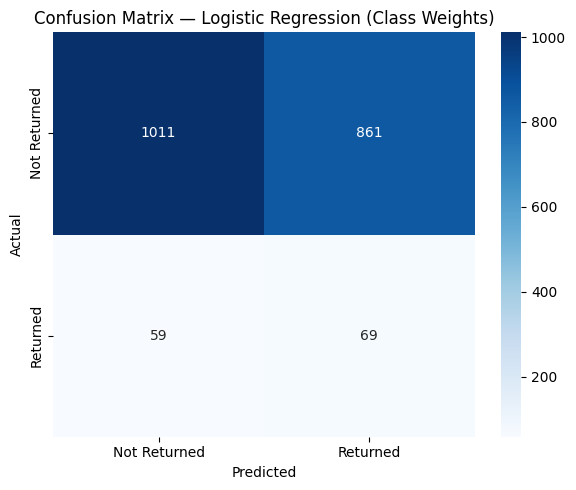


📊 Classification Report:
              precision    recall  f1-score   support

Not Returned       0.94      0.54      0.69      1872
    Returned       0.07      0.54      0.13       128

    accuracy                           0.54      2000
   macro avg       0.51      0.54      0.41      2000
weighted avg       0.89      0.54      0.65      2000



In [17]:
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Returned", "Returned"],
            yticklabels=["Not Returned", "Returned"])
plt.title(f"Confusion Matrix — {best_row['Model']} ({best_row['Technique']})")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred_best, 
                            target_names=["Not Returned", "Returned"]))

### save the best model

In [18]:
os.makedirs("../models", exist_ok=True)

model_path = "../models/best_model.pkl"
with open(model_path, "wb") as f:
    pickle.dump(best_model, f)

# Save feature names for API use later
feature_names = X_test.columns.tolist()
with open("../models/feature_names.pkl", "wb") as f:
    pickle.dump(feature_names, f)

print(f"✅ Best model saved → {model_path}")
print(f"✅ Feature names saved → ../models/feature_names.pkl")
print(f"\nModel: {best_row['Model']} + {best_row['Technique']}")

✅ Best model saved → ../models/best_model.pkl
✅ Feature names saved → ../models/feature_names.pkl

Model: Logistic Regression + Class Weights
